# 实验一参考答案（教师版）

**第一讲：Pandas 数据结构与 Vibe Coding 入门**

三个任务对应三份真实数据集：`航天进出口额.xlsx`、`karate.gml`、`airports.json`。

---

## 评分细则

| 任务                | 满分 | 评分要点                                                                                                      |
| ------------------- | ---- | ------------------------------------------------------------------------------------------------------------- |
| 任务1：航天贸易分析 | 25分 | 指标列解析+进口筛选(5) + 柱状图Top10含数值标签(7) + 折线图趋势含标题轴标签(6) + 箱线图Top5分布含异常值标注(7) |
| 任务2：社交网络     | 35分 | 基本网络图(10) + 最短路径分析+柱状图(15) + 路径红色高亮(10)                                                   |
| 任务3：机场3D       | 40分 | JSON解析正确(10) + 3D散点图正确(15) + 轴范围/视角/单位转换(15)                                                |

---

## 任务1：航天贸易数据分析（满分参考）

**数据**：`航天进出口额.xlsx`（国家统计局海关总署月度贸易数据，42国/地区，24个月）
**库**：Pandas + Matplotlib

### 满分 Prompt

**Round 1**：`读取 航天进出口额.xlsx，展示数据信息，解析指标列拆出方向和国家，清洗缺失值，用柱状图、折线图和箱线图展示贸易分布`

**Round 2**：`在保持上面代码的前提下：1.用split('_')拆指标列得方向/国家 2.筛选进口额，算各国24个月合计取Top10 3.柱状图Top10进口来源国加数值标签 4.折线图某国24月趋势加标题轴标签 5.箱线图Top5国家月度分布，红色标注异常值 6.中文支持`


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# ── 数据读取 ──
df = pd.read_excel('../实验一/航天进出口额.xlsx', sheet_name='Sheet0')
print('原始数据形状:', df.shape)
print('列名:', df.columns.tolist()[:10], '...')
df.head()

原始数据形状: (76, 29)
列名: ['指标', '进出口', '地区', '频度', '单位', '2022-01', '2022-02', '2022-03', '2022-04', '2022-05'] ...


,指标,进出口,地区,频度,单位,2022-01,2022-02,2022-03,2022-04,2022-05,...,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12
0,进口额(人民币)_(HS88章)航空器、航天器及其零件_印度_当期,进口,全国,月,万元,288.13,601.83,277.40,937.0,460.15,...,558.96,603.73,309.91,240.31,164.48,398.07,540.10,608.22,827.64,795.53
1,进口额(人民币)_(HS88章)航空器、航天器及其零件_中国香港_当期,进口,全国,月,万元,5.54,1.52,NaN,NaN,0.92,...,14.58,2.05,4.38,0.14,NaN,1.41,2.33,6.13,15.03,4.99
2,进口额(人民币)_(HS88章)航空器、航天器及其零件_日本_当期,进口,全国,月,万元,2653.87,1473.53,1739.32,690.0,2964.17,...,1968.32,4095.97,1971.03,1433.03,183.06,1970.47,2156.61,1691.27,1367.80,3274.18
3,进口额(人民币)_(HS88章)航空器、航天器及其零件_马来西亚_当期,进口,全国,月,万元,1668.97,852.08,1181.90,851.0,796.75,...,622.12,444.11,969.27,1039.92,466.36,2095.01,486.83,248.55,966.05,1326.76
4,进口额(人民币)_(HS88章)航空器、航天器及其零件_中国台湾_当期,进口,全国,月,万元,1189.64,421.17,955.36,316.0,1415.12,...,1147.03,1007.53,1309.67,1603.82,1245.61,1596.20,678.20,1208.12,635.39,915.41


In [ ]:
# ── 指标列解析 ──
# 指标列形如：进口额(人民币)_(HS88章)航空器、航天器及其零件_日本_当期
df['方向'] = df['指标'].apply(lambda s: s.split('_')[0].split('(')[0])
df['国家'] = df['指标'].apply(lambda s: s.split('_')[-2] if '_' in s else None)

# 月份列
month_cols = [c for c in df.columns if c.startswith(
    '2022') or c.startswith('2023')]
print(f'月份列数: {len(month_cols)}')
print(f'方向分布:\n', df['方向'].value_counts())
print(f'国家数: {df["国家"].nunique()}')

月份列数: 24
方向分布:
 方向
出口额    41
进口额    35
Name: count, dtype: int64
国家数: 42


In [ ]:
# ── 缺失值处理 ──
print('月份列缺失值统计:')
missing = df[month_cols].isnull().sum()
print(missing[missing > 0])

# 策略：dropna 删除含缺失的行（严格分析）
df_clean = df.dropna(subset=month_cols, how='any').copy()
print(f'\ndropna 后行数: {len(df_clean)}（原 {len(df)}）')

月份列缺失值统计:
2022-01    5
2022-02    7
2022-03    4
2022-04    6
2022-05    4
2022-06    3
2022-07    3
2022-08    7
2022-09    5
2022-10    5
2022-11    5
2022-12    5
2023-01    7
2023-02    5
2023-03    5
2023-04    3
2023-05    3
2023-06    3
2023-07    5
2023-08    2
2023-09    4
2023-10    2
2023-11    6
dtype: int64

dropna 后行数: 63（原 76）


In [ ]:
# ── 筛选进口 + 计算年度合计 ──
df_import = df_clean[df_clean['方向'] == '进口额'].copy()
df_import['年度合计'] = df_import[month_cols].sum(axis=1)
df_import['月均值'] = df_import[month_cols].mean(axis=1)

# Top10 进口来源国
df_top10 = df_import.nlargest(10, '年度合计')
print('=== 进口 Top10 来源国 ===')
print(df_top10[['国家', '年度合计', '月均值']].reset_index(drop=True))

=== 进口 Top10 来源国 ===
    国家        年度合计            月均值
0   欧盟  9323854.78  388493.949167
1   法国  5203221.11  216800.879583
2   美国  5061660.21  210902.508750
3   德国  3820897.37  159204.057083
4  加拿大   558497.86   23270.744167
5   英国   266853.18   11118.882500
6  俄罗斯   164357.63    6848.234583
7  意大利   126055.40    5252.308333
8  西班牙    96361.38    4015.057500
9   韩国    82467.32    3436.138333


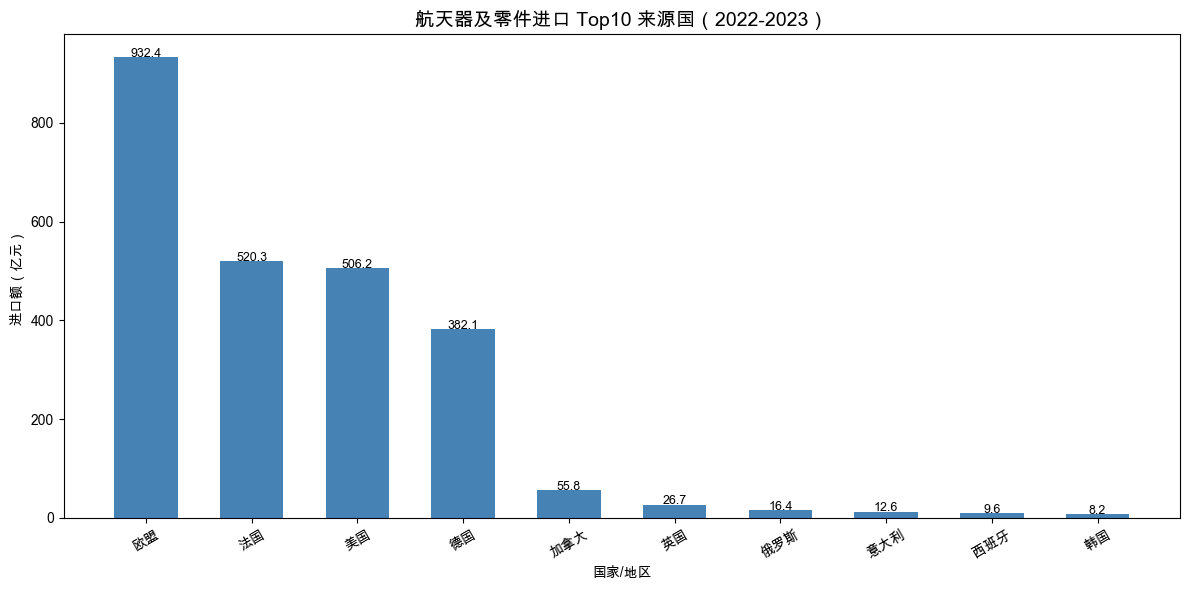

In [30]:
# ── 图1：柱状图 Top10 进口来源国 ──
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(df_top10['国家'], df_top10['年度合计'] /
              10000, color='steelblue', width=0.6)
ax.set_title('航天器及零件进口 Top10 来源国（2022-2023）', fontsize=14)
ax.set_xlabel('国家/地区')
ax.set_ylabel('进口额（亿元）')
plt.xticks(rotation=30)

# 数值标签
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

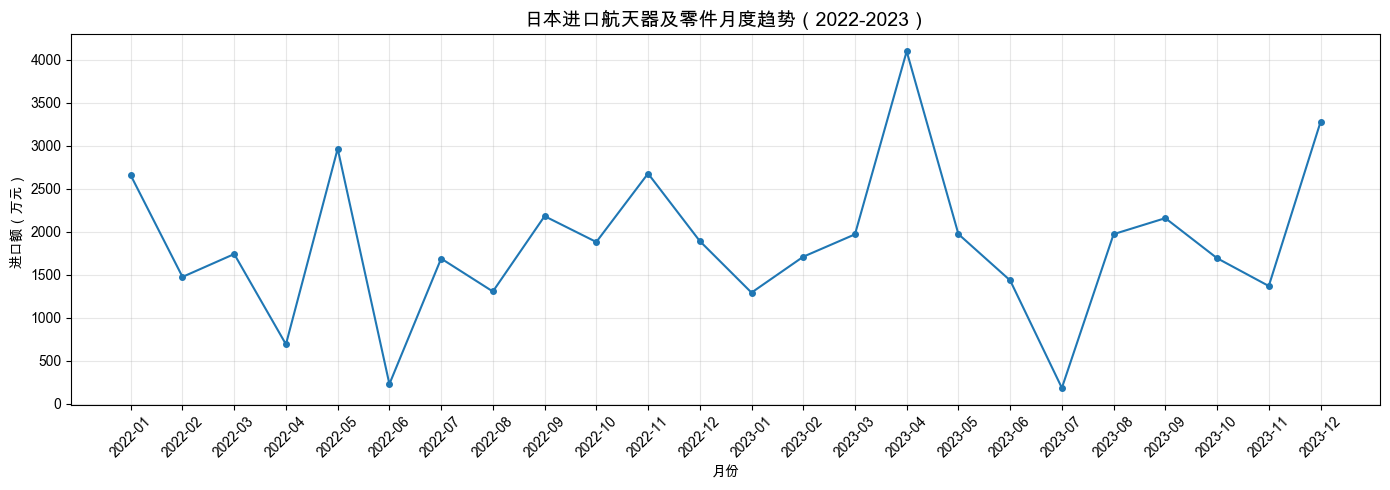

In [31]:
# ── 图2：折线图 日本 24 个月趋势 ──
row_japan = df_import[df_import['国家'] == '日本'].iloc[0]
values = [row_japan[c] for c in month_cols]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(month_cols, values, marker='o', markersize=4,
        linewidth=1.5, color='tab:blue')
ax.set_title('日本进口航天器及零件月度趋势（2022-2023）', fontsize=14)
ax.set_xlabel('月份')
ax.set_ylabel('进口额（万元）')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/8j/_jv21_yj3z35prvmn50wtjsh0000gn/T/ipykernel_89555/1740461906.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, flierprops=flier_props,


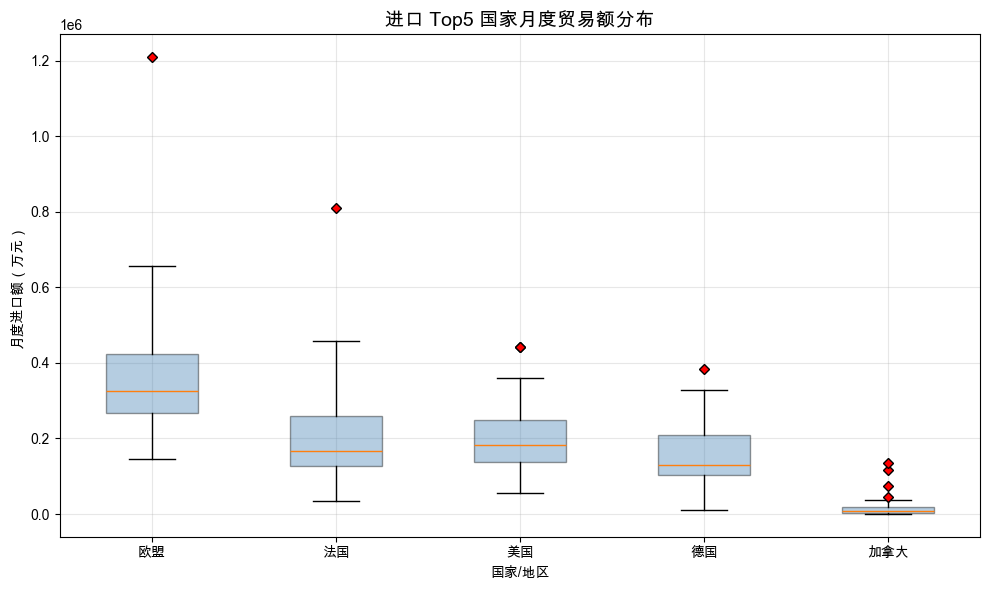

In [ ]:
# ── 图3：箱线图 Top5 国家月度分布 ──
df_top5 = df_import.nlargest(5, '年度合计')
data = [df_top5.iloc[i][month_cols].dropna().tolist()
        for i in range(len(df_top5))]
labels = df_top5['国家'].tolist()

flier_props = {'marker': 'D', 'markerfacecolor': 'red',
               'markeredgecolor': 'black', 'markersize': 5}

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(data, labels=labels, flierprops=flier_props,
           patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.4))
ax.set_title('进口 Top5 国家月度贸易额分布', fontsize=14)
ax.set_xlabel('国家/地区')
ax.set_ylabel('月度进口额（万元）')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 任务1考核说明

- **指标列解析+进口筛选(5分)**：正确 split('\_') 得到方向/国家两列，筛选方向=="进口额"
- **柱状图Top10(7分)**：Top10 正确 + 数值标签 + 标题/轴标签 + x轴旋转
- **折线图趋势(6分)**：某国 24 个月折线 + 标题/轴标签 + x轴旋转
- **箱线图分布(7分)**：Top5 国家数据正确 + 红色菱形异常值 + 标题

---

## 任务2：社交网络可视化（满分参考）

**数据**：`karate.gml`（34节点×78边，Zachary's Karate Club）
**库**：NetworkX + Matplotlib

### 满分 Prompt

**Round 1**：`读取 karate.gml，用 NetworkX 绘制社交网络图，显示节点标签，用 spring_layout 布局`

**Round 2**：`在保持上面代码的前提下：1.计算节点数/边数/平均度数 2.每个节点到其他所有节点的平均最短路径长度柱状图 3.10号节点到其他可达节点的距离分布直方图 4.红色高亮1→10最短路径 5.中文支持`


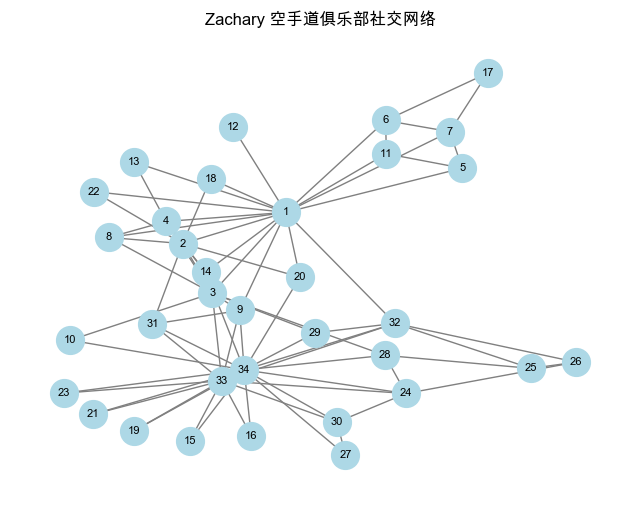

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (5, 3)

# ── 读取网络 ──
G = nx.read_gml('../实验一/karate.gml', label='id')
# 节点标签转整数
mapping = {node: int(node) for node in G.nodes()}
G = nx.relabel_nodes(G, mapping)

# 力导向布局
pos = nx.spring_layout(G, seed=42)

fig, ax = plt.subplots(figsize=(8, 6))
nx.draw(G, pos, node_color='lightblue', node_size=400,
        with_labels=True, font_size=8, edge_color='gray', ax=ax)
ax.set_title('Zachary 空手道俱乐部社交网络')
plt.show()

节点数: 34
边数: 78
平均度数: 4.59


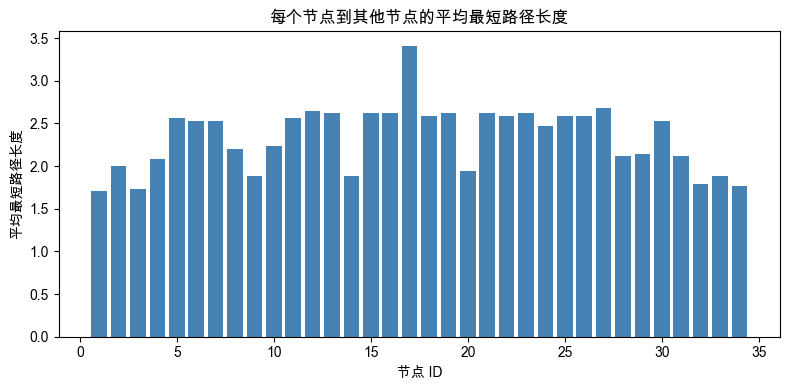

In [ ]:
# ── 网络指标 ──
N = G.number_of_nodes()
E = G.number_of_edges()
avg_deg = 2 * E / N
print(f'节点数: {N}')
print(f'边数: {E}')
print(f'平均度数: {avg_deg:.2f}')

# 每个节点的平均最短路径长度
spl = dict(nx.shortest_path_length(G))
avg_spl = [np.mean(list(d.values())) for d in spl.values()]

# 柱状图
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, N+1), avg_spl, color='steelblue')
ax.set_xlabel('节点 ID')
ax.set_ylabel('平均最短路径长度')
ax.set_title('每个节点到其他节点的平均最短路径长度')
plt.tight_layout()
plt.show()

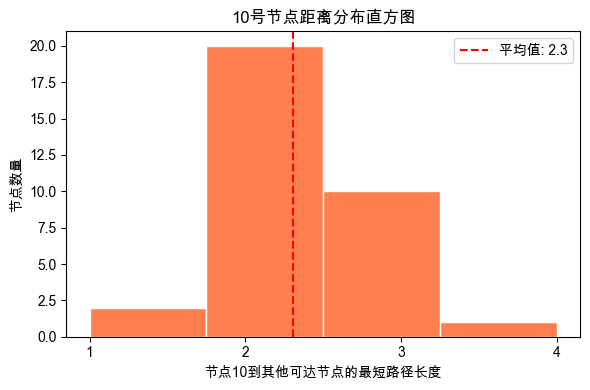

In [ ]:
# ── 10号节点到其他节点的距离分布 ──
dist_10 = nx.shortest_path_length(G, source=10)
del dist_10[10]  # 去掉自身
max_dist = max(dist_10.values())

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(list(dist_10.values()), bins=max_dist,
        color='coral', edgecolor='white')
ax.set_xticks(range(1, max_dist+1))
ax.set_xlabel('节点10到其他可达节点的最短路径长度')
ax.set_ylabel('节点数量')
ax.set_title('10号节点距离分布直方图')

# 标注平均值
avg_dist_10 = np.mean(list(dist_10.values()))
ax.axvline(avg_dist_10, color='red', linestyle='--',
           label=f'平均值: {avg_dist_10:.1f}')
ax.legend()
plt.tight_layout()
plt.show()

1→10 最短路径: 1 → 3 → 10


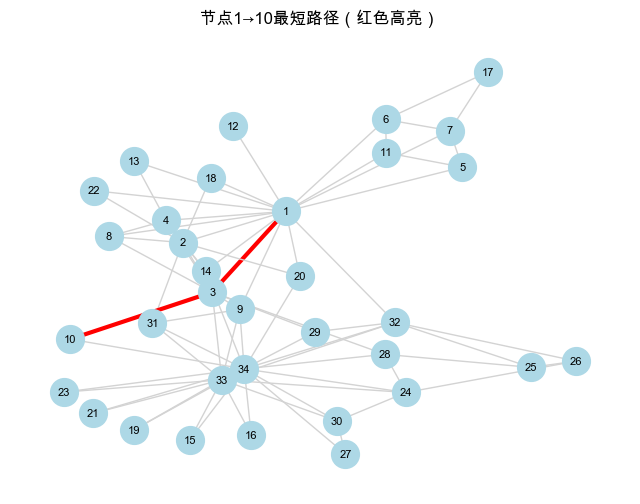

In [ ]:
# ── 高亮 1→10 最短路径 ──
target_path = nx.shortest_path(G, source=1, target=10)
print(f'1→10 最短路径: {" → ".join(map(str, target_path))}')

path_edges = set(zip(target_path[:-1], target_path[1:]))
edge_colors = ['red' if (u, v) in path_edges or (v, u) in path_edges else 'lightgray'
               for u, v in G.edges()]

fig, ax = plt.subplots(figsize=(8, 6))
nx.draw(G, pos, node_color='lightblue', node_size=400,
        with_labels=True, font_size=8, edge_color=edge_colors,
        width=[3 if c == 'red' else 1 for c in edge_colors], ax=ax)
ax.set_title('节点1→10最短路径（红色高亮）')
plt.show()

### 任务2考核说明

- **基本网络图(10分)**：spring_layout + 节点标签
- **最短路径分析(15分)**：平均最短路径柱状图(8) + 10号距离直方图含均值(7)
- **路径高亮(10分)**：1→10最短路径用红色加粗线标注

---

## 任务3：全球机场3D可视化（满分参考）

**数据**：`airports.json`（8.5MB，嵌套JSON）
**库**：Matplotlib 3D + JSON

### 满分 Prompt

**Round 1**：`读取 airports.json，提取所有机场的lat/lon/elevation，用 Matplotlib 3D 散点图展示全球机场空间分布`

**Round 2**：`1.elevation英尺转米(×0.3048) 2.轴范围：经度-200~200、纬度-60~60、海拔0~4000 3.加轴标签 4.视角仰角30方位角45 5.中文支持`


In [38]:
import json
from matplotlib import pyplot as plt
from matplotlib.ticker import MultipleLocator

plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# ── 读取 JSON ──
with open('../实验一/airports.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

print(f'机场总数: {len(data)}')

# 提取坐标字段
lat, lon, alt = [], [], []
for code in data:
    airport = data[code]
    lat.append(airport['lat'])
    lon.append(airport['lon'])
    alt.append(airport['elevation'] * 0.3048)  # 英尺→米

print(f'纬度范围: {min(lat):.1f} ~ {max(lat):.1f}')
print(f'经度范围: {min(lon):.1f} ~ {max(lon):.1f}')
print(f'海拔范围: {min(alt):.0f} ~ {max(alt):.0f} 米')

机场总数: 28899
纬度范围: -90.0 ~ 82.5
经度范围: -179.9 ~ 180.0
海拔范围: -386 ~ 4561 米


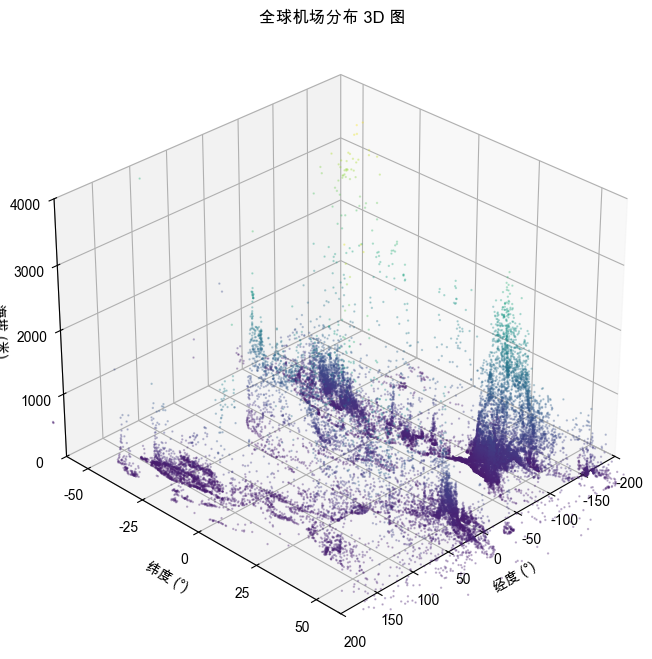

In [39]:
# ── 3D 散点图 ──
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 散点：半透明小点（数据量大）
ax.scatter(lon, lat, alt, s=0.5, alpha=0.3, c=alt, cmap='viridis')

# 轴范围
ax.set_xlim(-200, 200)
ax.set_xlabel('经度 (°)')
ax.set_ylim(-60, 60)
ax.set_ylabel('纬度 (°)')
ax.set_zlim(0, 4000)
ax.set_zlabel('海拔 (米)')

ax.xaxis.set_major_locator(MultipleLocator(50))
ax.yaxis.set_major_locator(MultipleLocator(25))
ax.zaxis.set_major_locator(MultipleLocator(1000))

ax.view_init(elev=30, azim=45)  # 仰角30°，方位角45°
ax.set_title('全球机场分布 3D 图')
plt.show()

### 任务3考核说明

- **JSON解析(10分)**：正确遍历嵌套dict，提取lat/lon/elevation
- **3D散点图(15分)**：projection='3d' + 数据正确投射
- **轴范围/视角/单位转换(15分)**：轴范围(5) + 视角(5) + 英尺→米(5)

---

## 思考题参考答案

**题目A**：在任务1的缺失值处理中——

- **dropna**：适用于缺失比例较低、对数据完整性要求高、无法合理估计真实值的场景
- **fillna 中位数**：适用于缺失比例较高、需保留样本量、数据有偏态（中位数比均值更鲁棒）的场景
- **本实验选择 dropna**：航天贸易数据月份列缺失 2-7 个，占总行数约 10%，属于少量缺失，删除后仍有 63 行可用于分析
